In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import joblib

In [2]:
df = pd.read_excel(
    "Data_Model_IoTMLCQ_2024.xlsx"
)

print("Dataset Shape:")
print(df.shape)

df.head()

Dataset Shape:
(4383, 28)


,Datetime,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,...,day,hour,oxigeno_scaled,ph,turbidez,Oxygenation Automatic,Corrective Measures,Thermal Risk Index,Low Oxygen Alert,Health Status
0,2024-01-01 00:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,0.0,8.355273,0.387898,0.020505,Yes,No,Normal,Safe,Stable
1,2024-01-01 01:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,1.0,8.256397,0.343950,0.108561,No,No,Normal,Safe,Stable
2,2024-01-01 02:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,2.0,8.511549,0.365285,0.410457,Yes,No,Normal,Safe,Stable
3,2024-01-01 03:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,3.0,8.362301,0.189601,0.891217,No,No,Normal,Safe,Stable
4,2024-01-01 04:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.3,1.0,...,1.0,4.0,8.003350,0.318775,0.936614,Yes,No,Normal,Safe,Stable


In [3]:
print("Health Status Distribution:")

display(
    df["Health Status"]
    .value_counts()
)

print("\nDescriptive Statistics:")

display(
    df.describe()
)

Health Status Distribution:


Health Status
Stable     3678
At Risk     705
Name: count, dtype: int64


Descriptive Statistics:


,Datetime,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,month_x,...,Average Temperature (°C),High Temperature (°C),Low Temperature (°C),Precipitation (inches),month_y,day,hour,oxigeno_scaled,ph,turbidez
count,4383,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,...,4.383000e+03,4383.0,4.383000e+03,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000
mean,2024-04-01 07:00:00,273.391088,93.857269,1.159480,27.344908,6.929651,7.829938,3.305640,3.570842,3.570842,...,2.910000e+01,33.9,2.410000e+01,2.752136,3.570842,14.823409,2.559890,8.128748,0.497172,0.067079
min,2024-01-01 00:00:00,262.050000,92.850000,1.000000,26.500000,6.340000,7.340000,2.790000,1.000000,1.000000,...,2.910000e+01,33.9,2.410000e+01,0.200000,1.000000,1.000000,0.000000,7.351139,0.152460,-0.061096
25%,2024-02-15 15:30:00,262.820000,92.930000,1.000000,26.600000,6.390000,7.880000,2.790000,2.000000,2.000000,...,2.910000e+01,33.9,2.410000e+01,0.510000,2.000000,7.947368,1.315789,7.993253,0.385936,0.001171
50%,2024-04-01 07:00:00,275.820000,92.960000,1.000000,27.450000,6.680000,7.890000,3.300000,4.000000,4.000000,...,2.910000e+01,33.9,2.410000e+01,3.990000,4.000000,14.945055,2.631579,8.146549,0.403914,0.013025
75%,2024-05-16 22:30:00,278.100000,95.270000,1.000000,27.700000,7.720000,7.970000,3.710000,5.000000,5.000000,...,2.910000e+01,33.9,2.410000e+01,4.750000,5.000000,21.868421,3.947368,8.269705,0.537868,0.024612
max,2024-07-01 14:00:00,286.500000,96.300000,2.000000,28.350000,7.890000,7.980000,3.980000,6.000000,6.000000,...,2.910000e+01,33.9,2.410000e+01,5.960000,6.000000,28.000000,5.000000,8.900171,1.029118,1.016684
std,NaN,8.675050,1.337427,0.361408,0.619734,0.631683,0.214384,0.431041,1.716562,1.716562,...,3.553119e-15,0.0,3.553119e-15,2.260136,1.716562,8.028951,1.490357,0.203954,0.205029,0.204358


In [4]:
X = df[[
    'Temperature (°C)',
    'Dissolved Oxygen (mg/L)',
    'pH',
    'Turbidity (NTU)',
    'hour'
]]

y = df['Health Status']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

print("Training Data:", len(X_train))
print("Testing Data :", len(X_test))

Training Data: 3506
Testing Data : 877


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [7]:
svm = SVC(

    kernel='rbf',

    random_state=42

)

svm.fit(
    X_train_scaled,
    y_train
)

print(
    "SVM Training Finished"
)

SVM Training Finished


In [8]:
svm_pred = svm.predict(
    X_test_scaled
)

In [9]:
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print(
    "Accuracy:",
    round(
        svm_accuracy * 100,
        4
    ),
    "%"
)

print(
    classification_report(
        y_test,
        svm_pred
    )
)

Accuracy: 99.7719 %
              precision    recall  f1-score   support

     At Risk       0.99      1.00      0.99       138
      Stable       1.00      1.00      1.00       739

    accuracy                           1.00       877
   macro avg       0.99      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877



In [10]:
svm_precision = precision_score(
    y_test,
    svm_pred,
    average='weighted'
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    average='weighted'
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average='weighted'
)

evaluation_table = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ]

})

evaluation_table

,Metric,Value
0,Accuracy,0.997719
1,Precision,0.997752
2,Recall,0.997719
3,F1 Score,0.997726


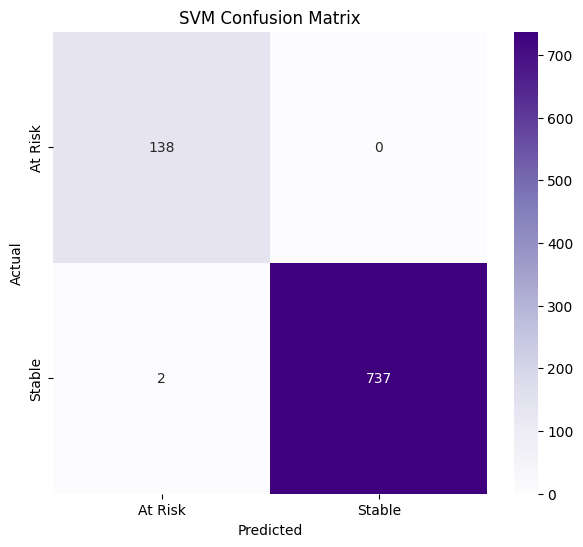

In [11]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=svm.classes_,
    yticklabels=svm.classes_
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [12]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf'
    ))

])

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

scores = cross_val_score(

    pipeline,

    X,

    y,

    cv=cv,

    scoring='accuracy'

)

cv_table = pd.DataFrame({

    "Fold":[
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5"
    ],

    "Accuracy":scores

})

cv_table

,Fold,Accuracy
0,Fold 1,0.998860
1,Fold 2,0.998860
2,Fold 3,1.000000
3,Fold 4,0.998858
4,Fold 5,1.000000


In [13]:
print(
    "Mean Accuracy:",
    scores.mean()
)

Mean Accuracy: 0.9993155891556416


In [14]:
print(
    "Number of Support Vectors:"
)

print(
    svm.n_support_
)

Number of Support Vectors:
[14 15]


In [15]:
joblib.dump(
    svm,
    "aquaagent_svm.pkl"
)

print(
    "Model Saved"
)

Model Saved


In [16]:
sample = pd.DataFrame([{

    'Temperature (°C)':31,
    'Dissolved Oxygen (mg/L)':4.2,
    'pH':8.5,
    'Turbidity (NTU)':15,
    'hour':14

}])

sample_scaled = scaler.transform(
    sample
)

prediction = svm.predict(
    sample_scaled
)

print(
    "Sample Prediction:",
    prediction
)

Sample Prediction: ['Stable']


In [18]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": result.importances_mean

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,Temperature (°C),0.084607
1,Dissolved Oxygen (mg/L),0.053706
3,Turbidity (NTU),0.031357
2,pH,0.028050
4,hour,0.001026


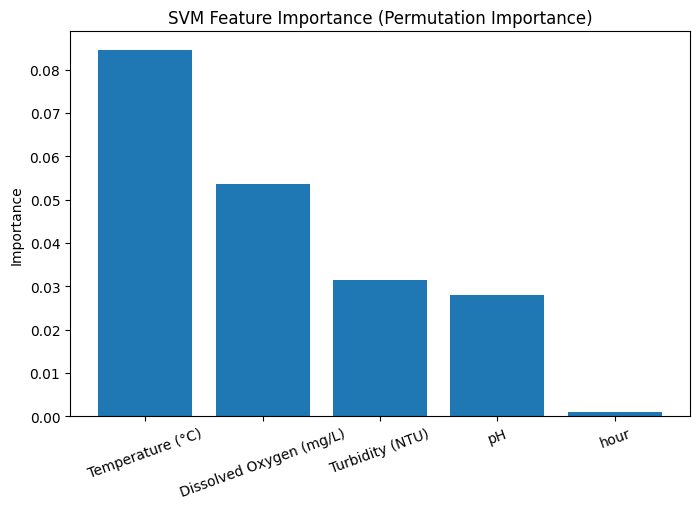

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "SVM Feature Importance (Permutation Importance)"
)

plt.ylabel(
    "Importance"
)

plt.xticks(rotation=20)

plt.show()

In [20]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],

    "Accuracy":[
        99.8860,
        99.7719,
        99.7719,
        99.8860
    ]

})

comparison

,Model,Accuracy
0,Decision Tree,99.8860
1,Logistic Regression,99.7719
2,SVM,99.7719
3,Random Forest,99.8860


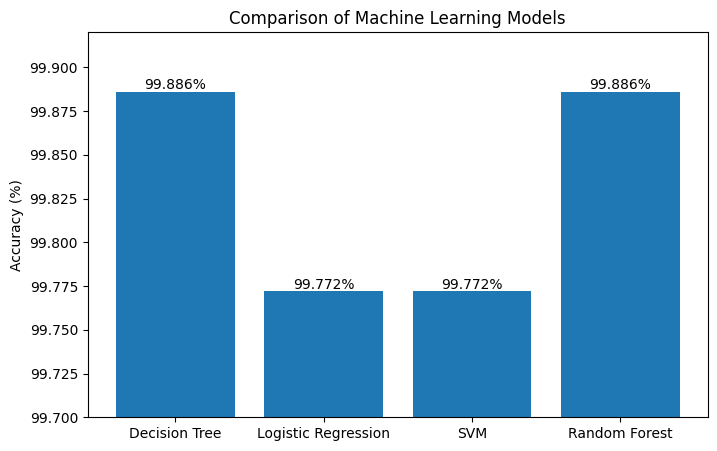

In [21]:
plt.figure(figsize=(8,5))

bars = plt.bar(

    comparison["Model"],
    comparison["Accuracy"]

)

plt.title(
    "Comparison of Machine Learning Models"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(
    99.7,
    99.92
)

for bar in bars:

    plt.text(

        bar.get_x() + bar.get_width()/2,

        bar.get_height(),

        f'{bar.get_height():.3f}%',

        ha='center',

        va='bottom'

    )

plt.show()

In [22]:
rf_importance = pd.DataFrame({

    "Feature":[

        "Temperature",

        "DO",

        "pH",

        "Turbidity",

        "Hour"

    ],

    "Importance":[

        45.55,

        34.54,

        13.33,

        6.57,

        0.01

    ]

})

rf_importance

,Feature,Importance
0,Temperature,45.55
1,DO,34.54
2,pH,13.33
3,Turbidity,6.57
4,Hour,0.01


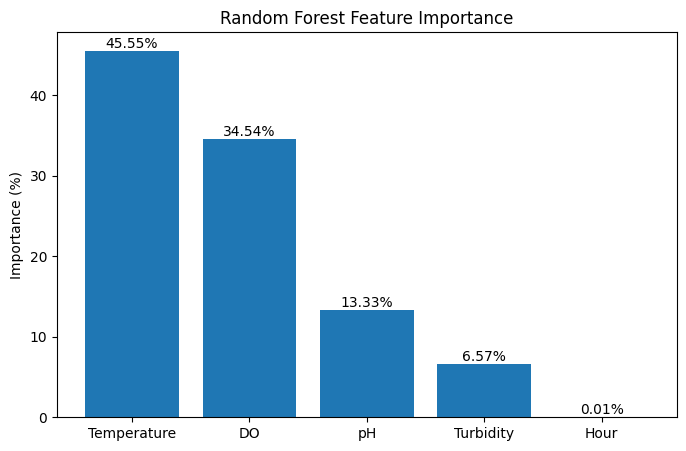

In [23]:
plt.figure(figsize=(8,5))

bars = plt.bar(

    rf_importance["Feature"],

    rf_importance["Importance"]

)

plt.title(
    "Random Forest Feature Importance"
)

plt.ylabel(
    "Importance (%)"
)

for bar in bars:

    plt.text(

        bar.get_x() + bar.get_width()/2,

        bar.get_height(),

        f'{bar.get_height():.2f}%',

        ha='center',

        va='bottom'

    )

plt.show()